Neste arquivo estarei testando a diferenciacao automatica com GradientTape do Tensorflow

In [1]:
import tensorflow as tf

In [2]:
x = tf.Variable(3.0)

x

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0>

Pode-se diferenciar uma função arbitraria, e aplicar a ela um tensor para obter o valor diferencial dela aplicado aos valores deste tensor (Neste caso o valor aplicado a função diferenciavel é 3.0)

In [3]:
with tf.GradientTape() as tape:
    #y = 3x^2 + 7x^3.
    y = 3*x**2 + 7*x**3
    
    #y' = 6x + 21x^2; y'(3.0) = 18 + 21*9 = 18 + 189 = 207
    dy_dx = tape.gradient(y, x)
    
    print(dy_dx)

tf.Tensor(207.0, shape=(), dtype=float32)


Caso com mais de uma varíavel:

In [4]:
y = tf.Variable(7.0)

y

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=7.0>

In [5]:
with tf.GradientTape() as tape:
    #z = 3*y^2 + 6*x^3
    z = 3*y**2 + 6*x**3

    variables = [x, y]
    
    dz_dx, dz_dy = tape.gradient(z, variables)


#dz/dx = 18*x^2, dz/dx(3.0, 7.0) = 18*3^2 = 18*9 = 162
print(dz_dx)

#dz/dy = 6*y, dz/dy(3.0, 7.0) = 6*7 = 42
print(dz_dy)


tf.Tensor(162.0, shape=(), dtype=float32)
tf.Tensor(42.0, shape=(), dtype=float32)


A seguir será mostrado o gráfico da função z(x,y), e o gradiente (invertido) dela aplicado ao ponto (3, 7), ou seja, qual é a direção de maior decrescimento de z(x,y) neste ponto:

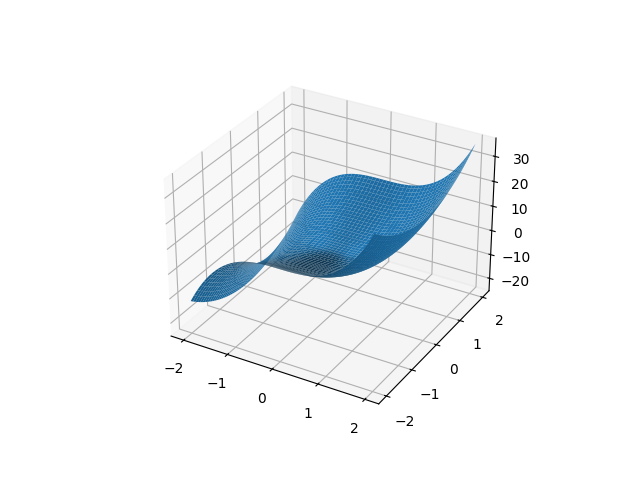

In [6]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = 3*(Y**2) + 3*(X**3)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z)

plt.show()



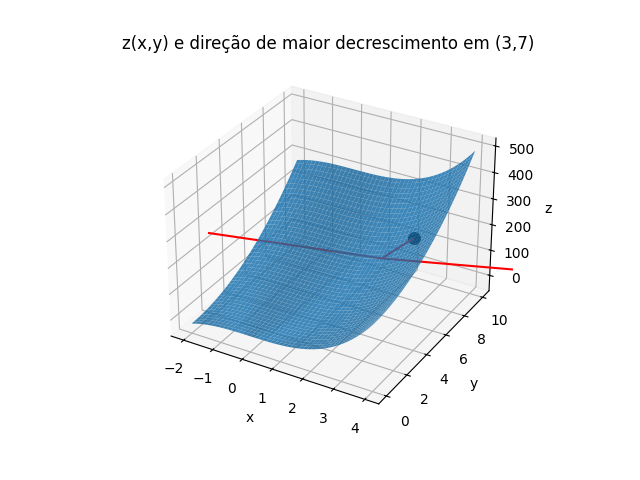

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.close('all')  # evita acumular linhas de execuções anteriores

# ---- Função z(x,y) ----
def z_tf(x, y):
    return 3.0*(y**2) + 3.0*(x**3)

# ---- Ponto ----
x0, y0 = 3.0, 7.0
x = tf.Variable(x0, dtype=tf.float32)
y = tf.Variable(y0, dtype=tf.float32)

with tf.GradientTape() as tape:
    z = z_tf(x, y)

dz_dx, dz_dy = tape.gradient(z, [x, y])

dz_dx = float(dz_dx.numpy())
dz_dy = float(dz_dy.numpy())
z0 = float(z.numpy())

g = np.array([dz_dx, dz_dy], dtype=float)
neg_g = -g
neg_g_unit = neg_g / np.linalg.norm(neg_g)

# tamanho visual do “passo” no plano xy
step_xy = 1.0
dx = neg_g_unit[0] * step_xy
dy = neg_g_unit[1] * step_xy

# variação em z (aprox) pra seta ficar “colada” na superfície
dz = g.dot(np.array([dx, dy]))

# ---- Superfície ----
xx = np.linspace(-2, 4, 180)
yy = np.linspace(0, 10, 180)
X, Y = np.meshgrid(xx, yy)
Z = z_tf(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# (opcional) remove as linhas da malha da superfície
ax.plot_surface(X, Y, Z, alpha=0.85, edgecolor='none', linewidth=0)

# ponto (3,7) preto
ax.scatter([x0], [y0], [z0], color='k', s=70)

# vetor de maior decrescimento vermelho
ax.quiver(
    x0, y0, z0,
    dx, dy, dz,
    color='r',
    arrow_length_ratio=0.25
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("z(x,y) e direção de maior decrescimento em (3,7)")

plt.show()
